In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/LungCancer_DataSet.csv")
print("Original coloumn headers:")
print(list(df.columns))

Original coloumn headers:
['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage', 'family_history', 'smoking_status', 'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type', 'end_treatment_date', 'survived']


## Handle missing values

Identify and address any missing values in the dataset, potentially using imputation or removal.


In [26]:
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
id                     0
age                    3
gender                18
country               26
diagnosis_date         0
cancer_stage           1
family_history         0
smoking_status        28
bmi                    6
cholesterol_level     23
hypertension          11
asthma                 6
cirrhosis              3
other_cancer           5
treatment_type        29
end_treatment_date     0
survived               0
dtype: int64


In [4]:
# Handling missing values in numerical columns with the mean
numerical_cols = ['age', 'bmi', 'cholesterol_level']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].mean())

# Handling missing values in categorical columns by imputing with the mode
categorical_cols_to_impute_mode = ['gender', 'country', 'cancer_stage', 'smoking_status', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type']
for col in categorical_cols_to_impute_mode:
    df[col] = df[col].fillna(df[col].mode()[0])


# Verify that all missing values have been handled
print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
id                    0
age                   0
gender                0
country               0
diagnosis_date        0
cancer_stage          0
family_history        0
smoking_status        0
bmi                   0
cholesterol_level     0
hypertension          0
asthma                0
cirrhosis             0
other_cancer          0
treatment_type        0
end_treatment_date    0
survived              0
dtype: int64


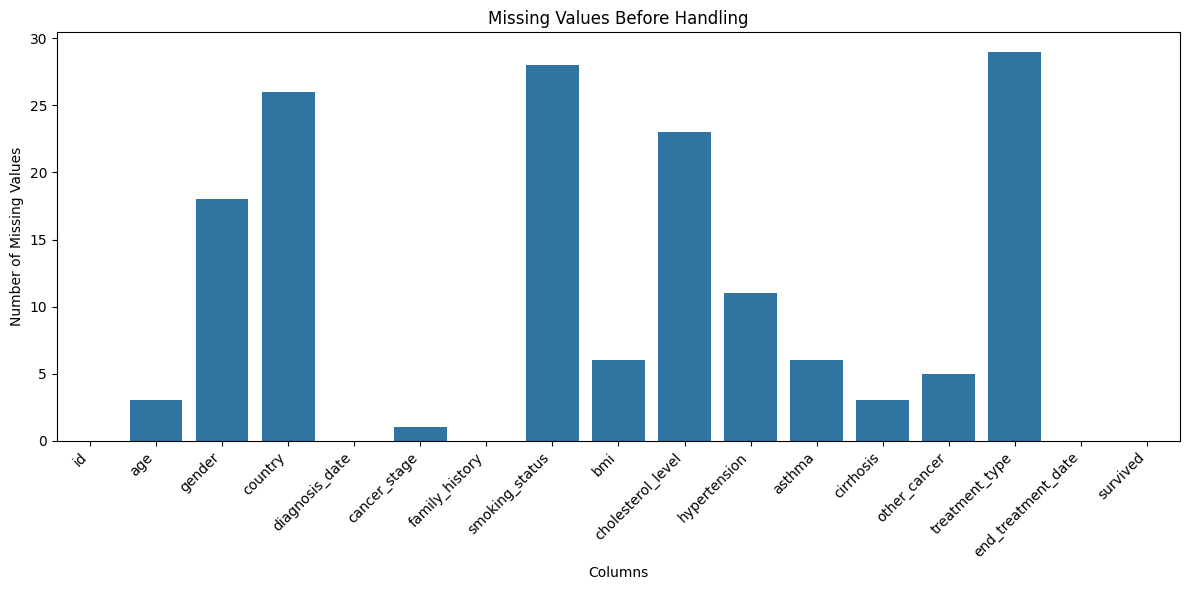

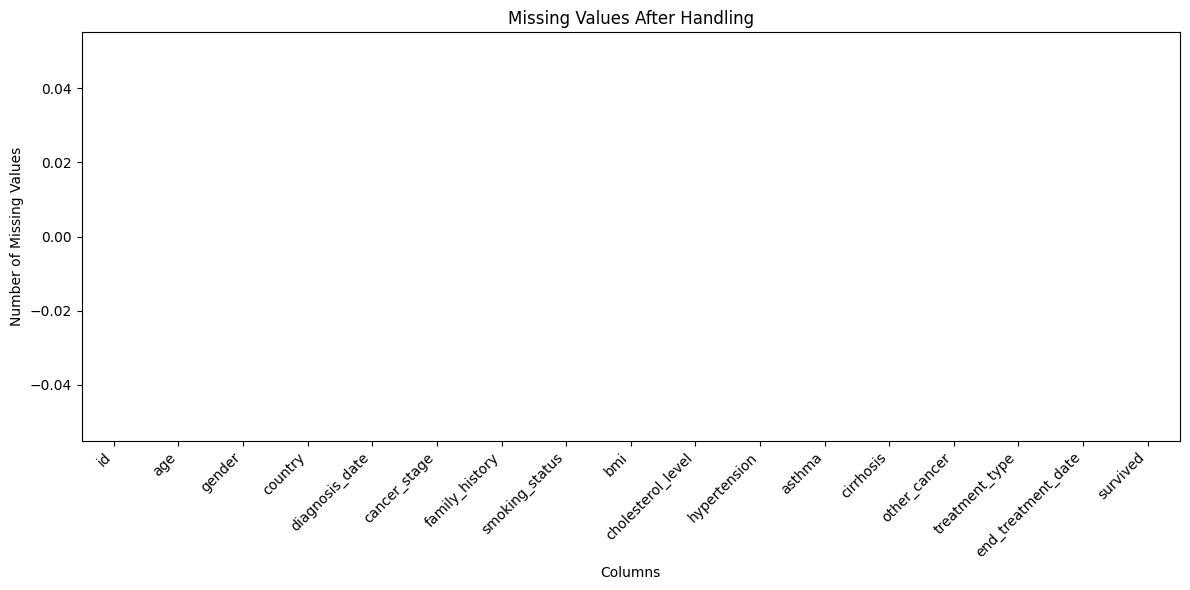

In [5]:
#Visualize missing values

df_original_smoking = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/LungCancer_DataSet.csv")

# Plot missing values before handling
plt.figure(figsize=(12, 6))
sns.barplot(x=df_original_smoking.columns, y=df_original_smoking.isnull().sum())
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values Before Handling')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot missing values after handling
plt.figure(figsize=(12, 6))
sns.barplot(x=df.columns, y=df.isnull().sum())
plt.xlabel('Columns')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values After Handling')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Encode categorical variables

Convert categorical features into a numerical format that can be used by machine learning algorithms.


In [6]:
categorical_cols_to_encode = ['gender', 'country', 'cancer_stage', 'smoking_status', 'treatment_type']
df = pd.get_dummies(df, columns=categorical_cols_to_encode) # Removed drop_first=True
print("DataFrame columns after one-hot encoding:")
print(list(df.columns))

DataFrame columns after one-hot encoding:
['id', 'age', 'diagnosis_date', 'family_history', 'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'end_treatment_date', 'survived', 'gender_Female', 'gender_Male', 'country_Austria', 'country_Belgium', 'country_Bulgaria', 'country_Croatia', 'country_Cyprus', 'country_Czech Republic', 'country_Denmark', 'country_Estonia', 'country_Finland', 'country_France', 'country_Germany', 'country_Greece', 'country_Hungary', 'country_Ireland', 'country_Italy', 'country_Latvia', 'country_Lithuania', 'country_Luxembourg', 'country_Malta', 'country_Netherlands', 'country_Poland', 'country_Portugal', 'country_Romania', 'country_Slovakia', 'country_Slovenia', 'country_Spain', 'country_Sweden', 'cancer_stage_Stage I', 'cancer_stage_Stage II', 'cancer_stage_Stage III', 'cancer_stage_Stage IV', 'smoking_status_Current Smoker', 'smoking_status_Former Smoker', 'smoking_status_Never Smoked', 'smoking_status_Passive Smoker', 'treatmen


Visualizing encoding for: gender


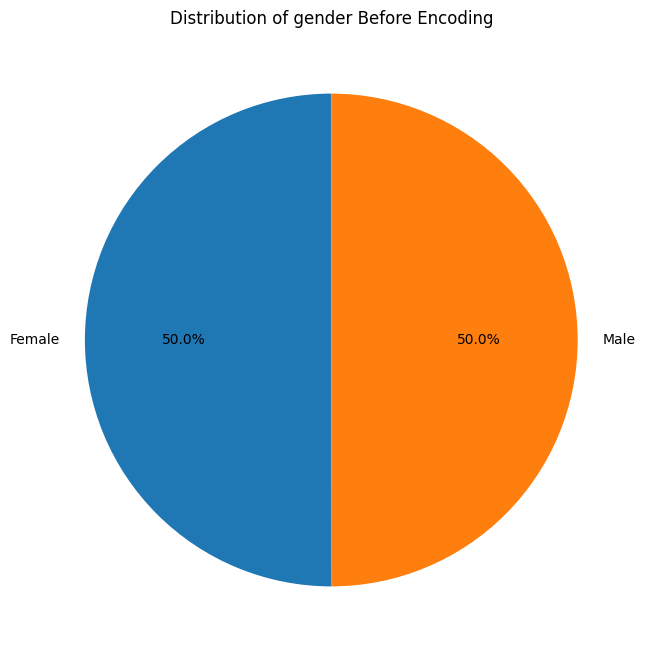

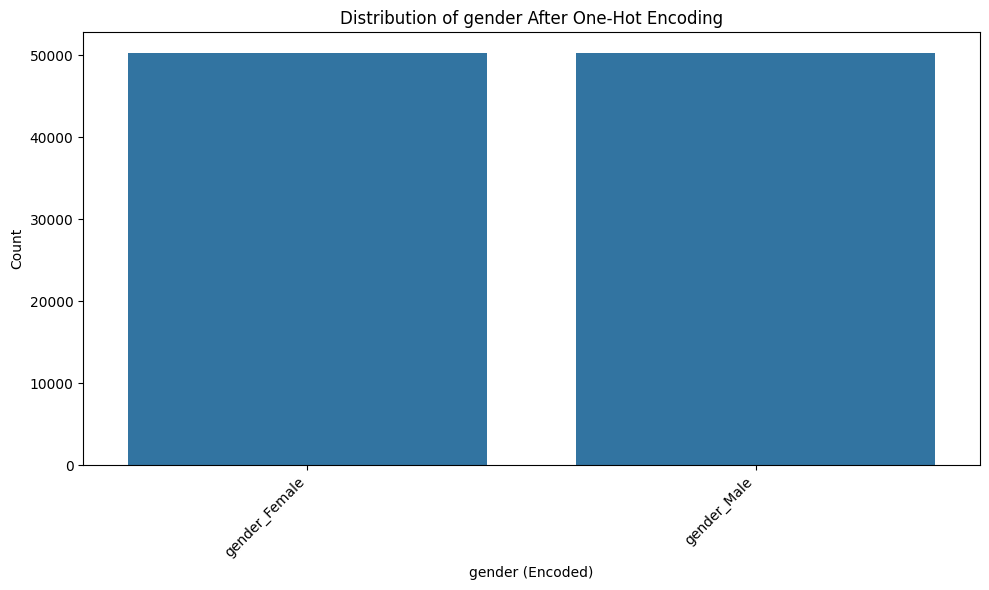


Counts of gender after One-Hot Encoding:
  gender (Encoded)  Count
0    gender_Female  50270
1      gender_Male  50238

Visualizing encoding for: country


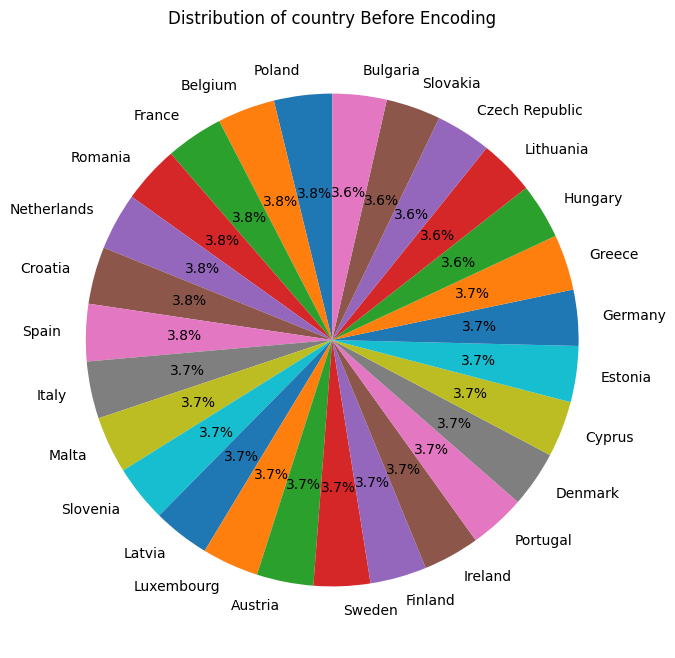

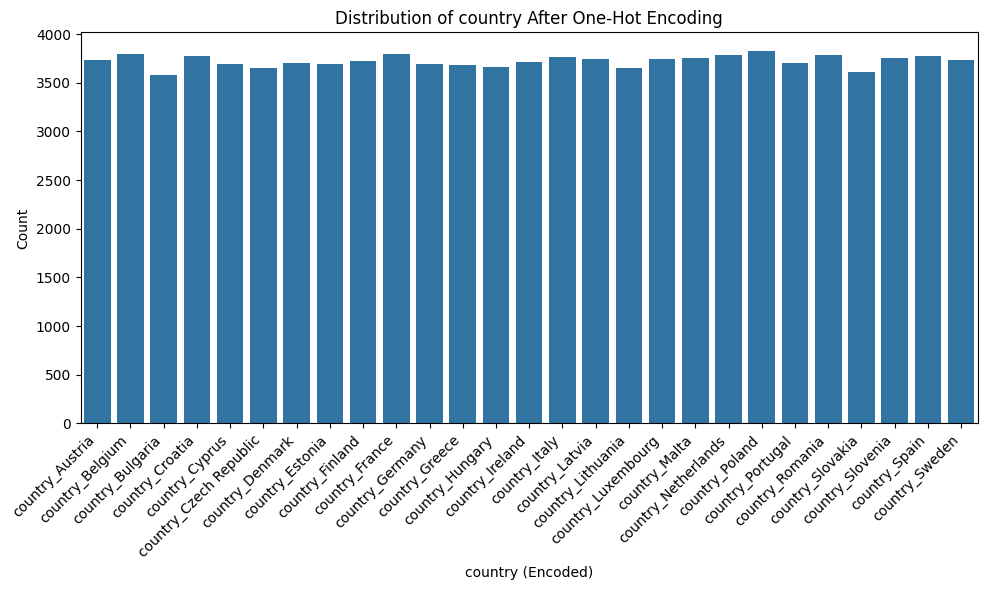


Counts of country after One-Hot Encoding:
         country (Encoded)  Count
0          country_Austria   3736
1          country_Belgium   3796
2         country_Bulgaria   3580
3          country_Croatia   3774
4           country_Cyprus   3693
5   country_Czech Republic   3648
6          country_Denmark   3702
7          country_Estonia   3693
8          country_Finland   3726
9           country_France   3791
10         country_Germany   3690
11          country_Greece   3678
12         country_Hungary   3658
13         country_Ireland   3717
14           country_Italy   3768
15          country_Latvia   3744
16       country_Lithuania   3656
17      country_Luxembourg   3740
18           country_Malta   3755
19     country_Netherlands   3786
20          country_Poland   3826
21        country_Portugal   3706
22         country_Romania   3787
23        country_Slovakia   3605
24        country_Slovenia   3754
25           country_Spain   3771
26          country_Sweden   3728

Visu

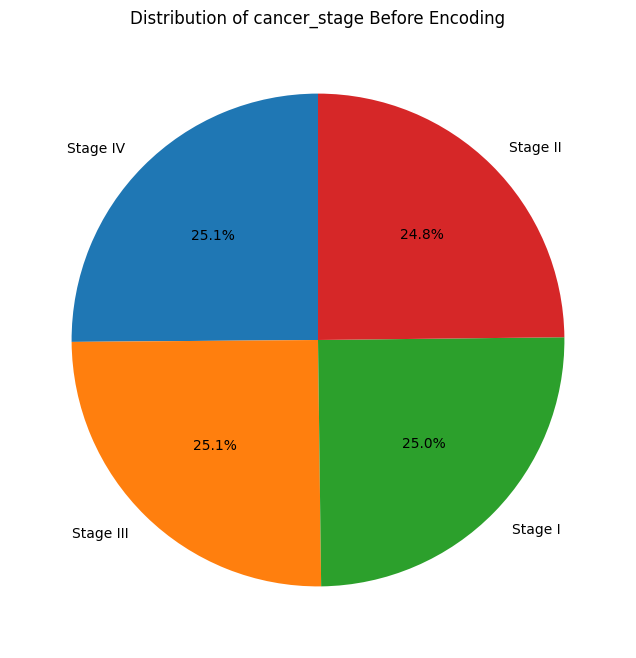

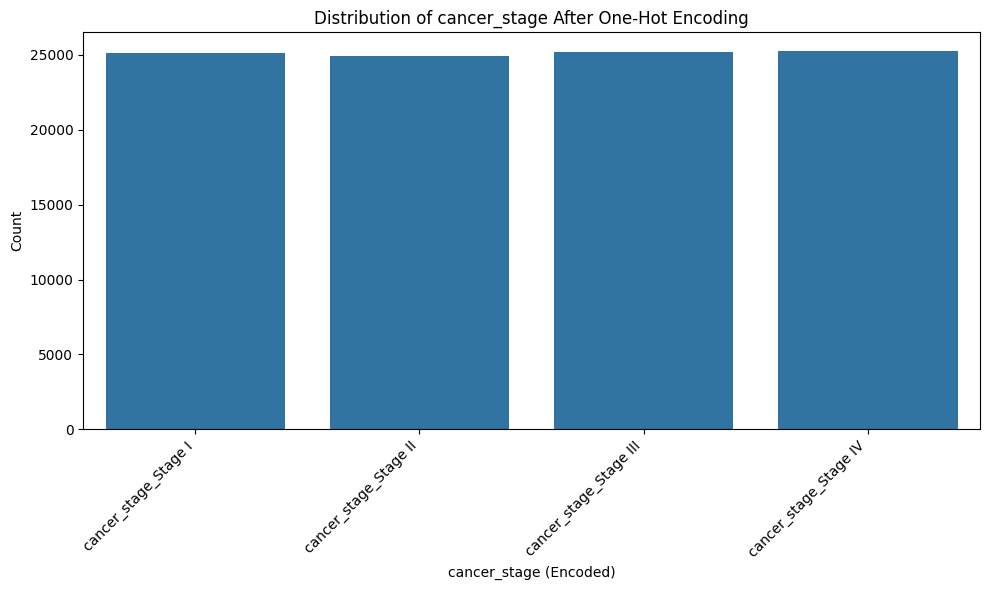


Counts of cancer_stage after One-Hot Encoding:
   cancer_stage (Encoded)  Count
0    cancer_stage_Stage I  25102
1   cancer_stage_Stage II  24947
2  cancer_stage_Stage III  25208
3   cancer_stage_Stage IV  25251

Visualizing encoding for: smoking_status


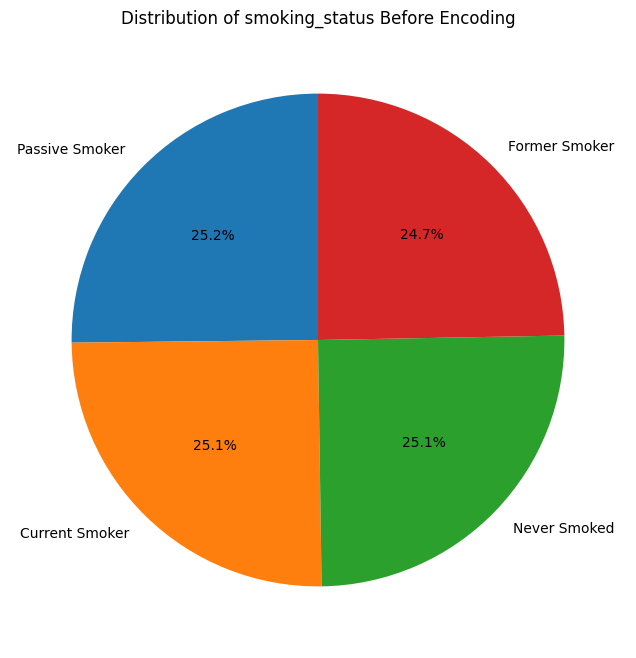

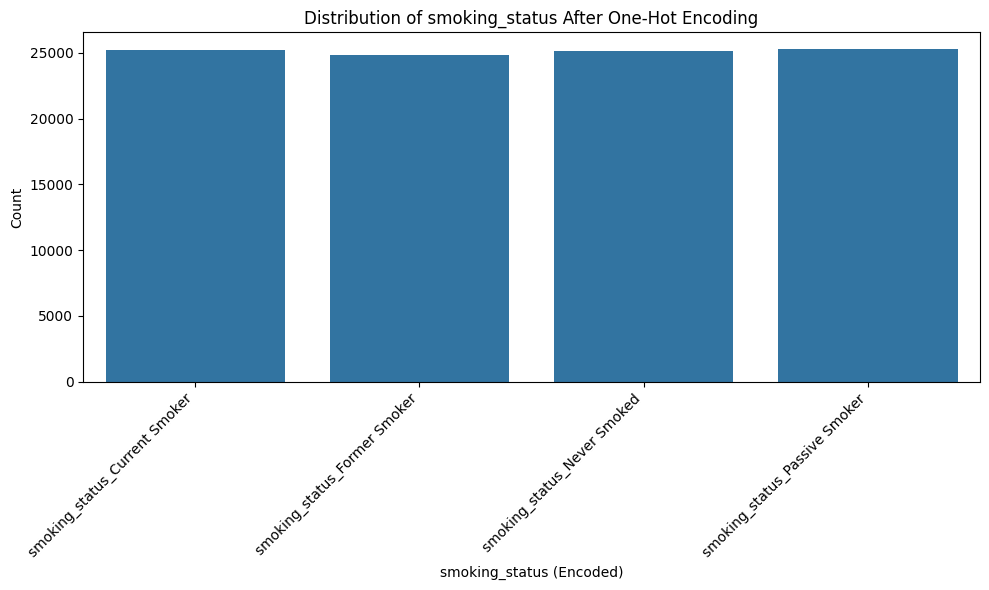


Counts of smoking_status after One-Hot Encoding:
        smoking_status (Encoded)  Count
0  smoking_status_Current Smoker  25187
1   smoking_status_Former Smoker  24837
2    smoking_status_Never Smoked  25183
3  smoking_status_Passive Smoker  25301

Visualizing encoding for: treatment_type


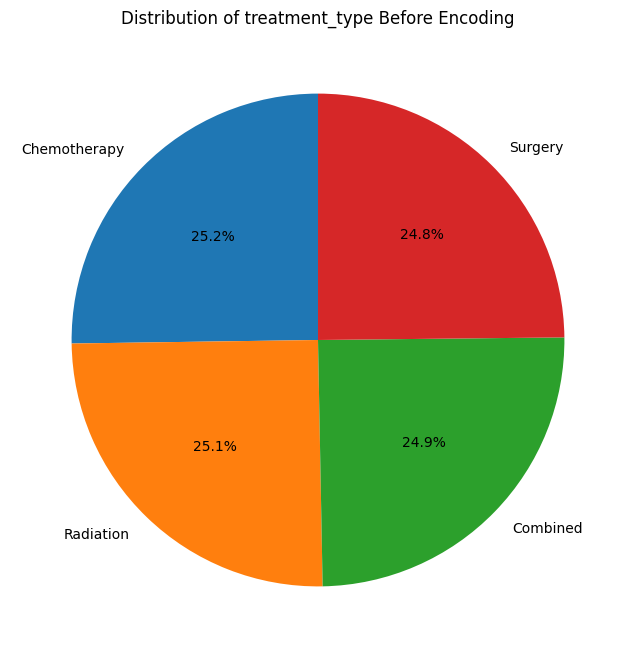

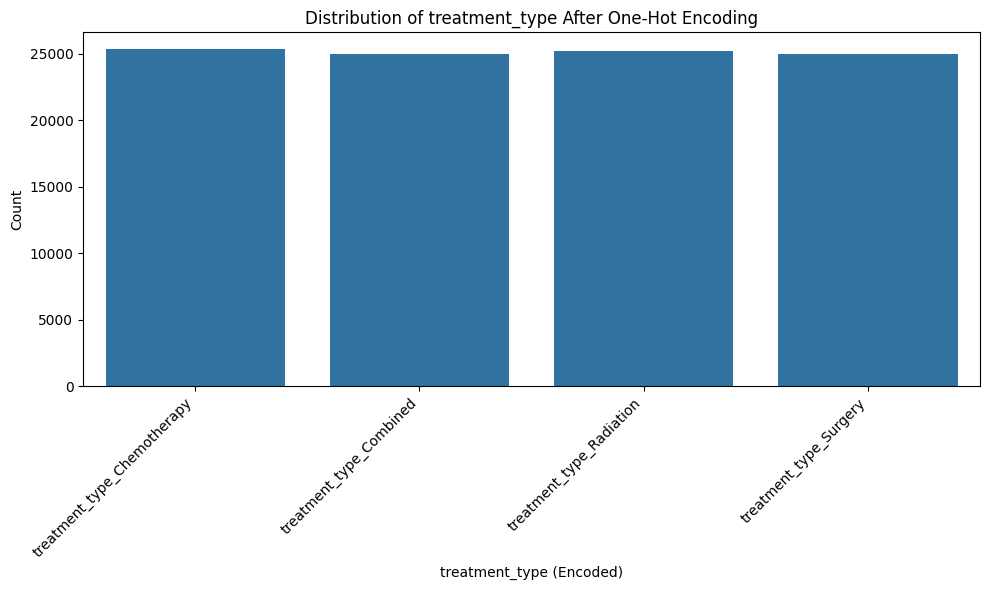


Counts of treatment_type after One-Hot Encoding:
      treatment_type (Encoded)  Count
0  treatment_type_Chemotherapy  25356
1      treatment_type_Combined  24995
2     treatment_type_Radiation  25200
3       treatment_type_Surgery  24957


In [7]:
# Define the list of categorical columns to visualize encoding for
categorical_cols_to_encode_viz = ['gender', 'country', 'cancer_stage', 'smoking_status', 'treatment_type']

# Ensure df_original_smoking is defined for "before" visualization
df_original_encoding = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/LungCancer_DataSet.csv")

# Fill missing values in these columns with mode for visualization as done previously
for col in categorical_cols_to_encode_viz:
    df_original_encoding[col] = df_original_encoding[col].fillna(df_original_encoding[col].mode()[0])


for col in categorical_cols_to_encode_viz:
    print(f"\nVisualizing encoding for: {col}")

    # Create a pie chart for the original column before encoding
    plt.figure(figsize=(8, 8))
    df_original_encoding[col].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
    plt.title(f'Distribution of {col} Before Encoding')
    plt.ylabel('') # Hide the default y-label for pie charts
    plt.show()

    # Create a bar plot for the one-hot encoded columns after encoding
    # Find the columns in the processed df that correspond to the original categorical column
    encoded_cols = [c for c in df.columns if c.startswith(f'{col}_')]
    if encoded_cols: # Check if any encoded columns were found
        df_encoded_counts = df[encoded_cols].sum().reset_index()
        df_encoded_counts.columns = [f'{col} (Encoded)', 'Count']

        plt.figure(figsize=(10, 6))
        sns.barplot(data=df_encoded_counts, x=f'{col} (Encoded)', y='Count')
        plt.title(f'Distribution of {col} After One-Hot Encoding')
        plt.xlabel(f'{col} (Encoded)')
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        print(f"\nCounts of {col} after One-Hot Encoding:")
        print(df_encoded_counts)
    else:
        print(f"No one-hot encoded columns found for {col}.")

## Scale numerical features

Standardize or normalize numerical features to ensure they have a similar range, preventing features with larger values from dominating the model.


In [8]:
numerical_cols = ['age', 'bmi', 'cholesterol_level']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print("Scaled numerical columns:")
print(df[numerical_cols].head())

Scaled numerical columns:
        age       bmi  cholesterol_level
0  0.906029 -0.129271          -0.796404
1 -0.495779  1.278996           1.063923
2  1.006159  1.613160           0.788319
3 -0.395650  1.493816           0.168210
4 -1.797459 -1.286913          -1.278711


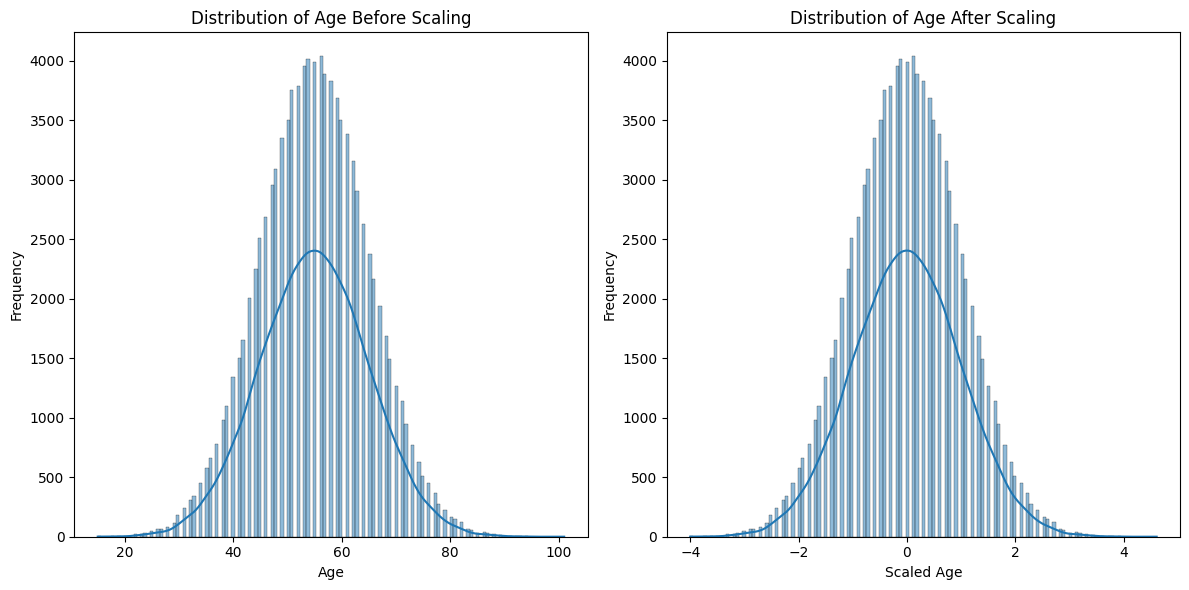

In [9]:
#Visualize numerical scaling
# Select the 'age' column from the original and scaled DataFrames
age_original = df_original_smoking['age']
age_scaled = df['age']

# Create histograms
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(age_original, kde=True)
plt.title('Distribution of Age Before Scaling')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(age_scaled, kde=True)
plt.title('Distribution of Age After Scaling')
plt.xlabel('Scaled Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Handle outliers

Identify and address outliers in the data, as they can negatively impact model performance.


In [10]:
numerical_cols_for_outliers = ['age', 'bmi', 'cholesterol_level']

for col in numerical_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    median_value = df[col].median()

    df[col] = df[col].apply(lambda x: median_value if x < lower_bound or x > upper_bound else x)

print("Outliers handled in the following columns:")
print(numerical_cols_for_outliers)

Outliers handled in the following columns:
['age', 'bmi', 'cholesterol_level']


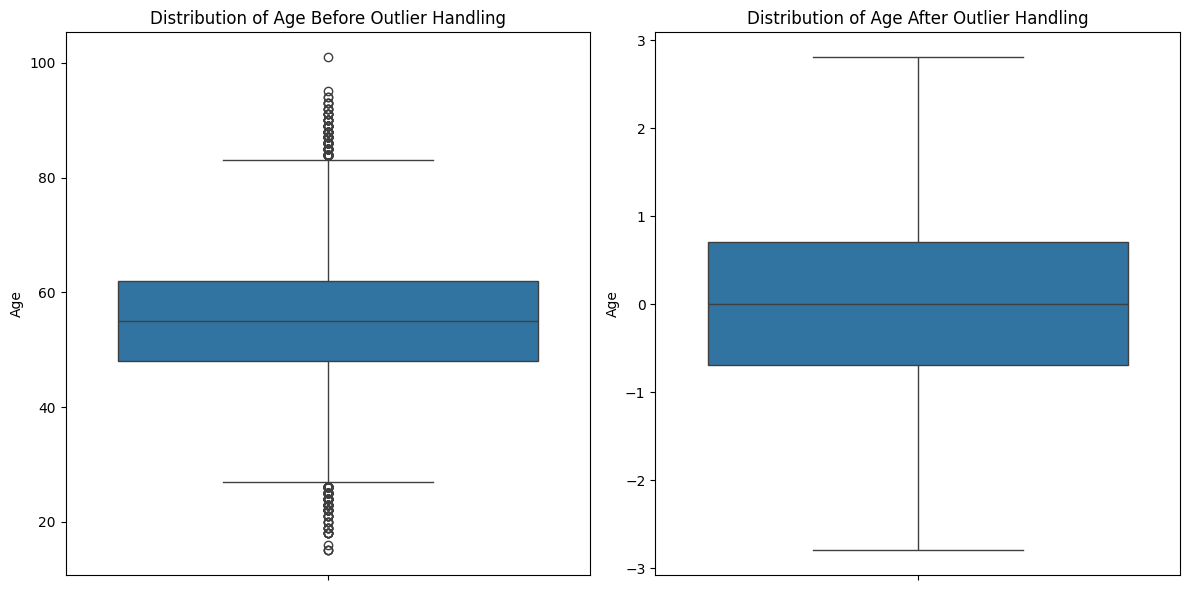


Number of outliers before handling:
  age: 435 outliers
  bmi: 0 outliers
  cholesterol_level: 0 outliers


In [11]:
# Define df_original_smoking by reading the CSV
df_original_smoking = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/LungCancer_DataSet.csv")


plt.figure(figsize=(12, 6))

# Boxplot before outlier handling
plt.subplot(1, 2, 1)
sns.boxplot(y=df_original_smoking['age'])
plt.title('Distribution of Age Before Outlier Handling')
plt.ylabel('Age')

# Boxplot after outlier handling
plt.subplot(1, 2, 2)
sns.boxplot(y=df['age'])
plt.title('Distribution of Age After Outlier Handling')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

# Calculate and print the number of outliers before handling
numerical_cols_for_outliers = ['age', 'bmi', 'cholesterol_level']

print("\nNumber of outliers before handling:")
for col in numerical_cols_for_outliers:
    Q1 = df_original_smoking[col].quantile(0.25)
    Q3 = df_original_smoking[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify and count outliers in the original data
    outliers_before = df_original_smoking[(df_original_smoking[col] < lower_bound) | (df_original_smoking[col] > upper_bound)].shape[0]

    print(f"  {col}: {outliers_before} outliers")

## Handle Duplicate values

Delete Duplicate values in the data set.


In [14]:
# Display the number of rows before removing duplicates
print(f"Number of rows before removing duplicates: {len(df)}")

# Remove duplicate rows
df_cleaned = df.drop_duplicates()

# Display the number of rows after removing duplicates
print(f"Number of rows after removing duplicates: {len(df_cleaned)}")

# Display the first few rows of the cleaned DataFrame
display(df_cleaned.head())

Number of rows before removing duplicates: 100508
Number of rows after removing duplicates: 100211


,id,age,family_history,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,survived,...,cancer_stage_Stage IV,smoking_status_Current Smoker,smoking_status_Former Smoker,smoking_status_Never Smoked,smoking_status_Passive Smoker,treatment_type_Chemotherapy,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery,treatment_duration
0,1,0.906029,Yes,-0.129271,-0.796404,0.0,0.0,1.0,0.0,0,...,False,False,False,False,True,True,False,False,False,523
1,2,-0.495779,Yes,1.278996,1.063923,1.0,1.0,0.0,0.0,1,...,False,False,False,False,True,False,False,False,True,424
2,3,1.006159,Yes,1.613160,0.788319,1.0,1.0,0.0,0.0,0,...,False,False,True,False,False,False,True,False,False,370
3,4,-0.395650,No,1.493816,0.168210,1.0,1.0,0.0,0.0,0,...,False,False,False,False,True,True,False,False,False,443
4,5,-1.797459,No,-1.286913,-1.278711,0.0,0.0,0.0,0.0,0,...,False,False,False,False,True,False,True,False,False,406


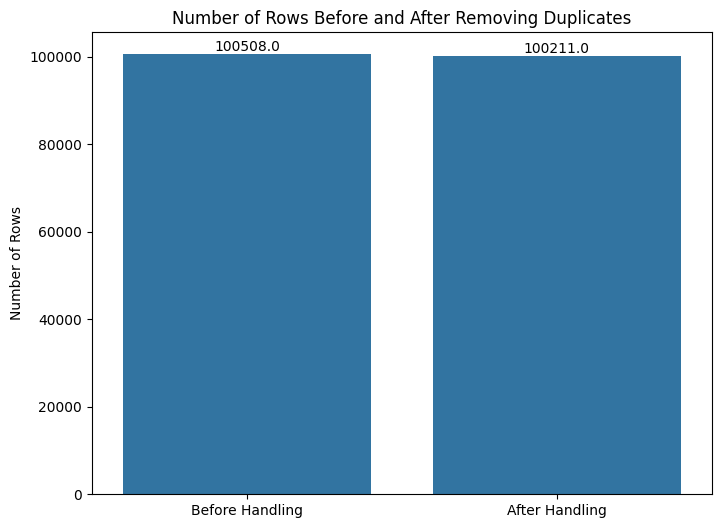

In [15]:
#visual representation of duplicates before handling
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=['Before Handling', 'After Handling'], y=[len(df), len(df_cleaned)])
plt.ylabel('Number of Rows')
plt.title('Number of Rows Before and After Removing Duplicates')

# Add exact counts as text annotations
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

## Feature Selection

Select a subset of the original features by using SelectKBest method


In [20]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select the country columns
country_cols = [col for col in df_cleaned.columns if col.startswith('country_')]

# Define the target variable
# Assuming 'survived' is your target variable for feature selection
target = df_cleaned['survived']
features = df_cleaned[country_cols]

# Use SelectKBest to select the top k country features
# You can adjust the value of k based on your needs
k = 10  # For example, select the top 10 countries
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(features, target)

# Get the indices of the selected features
selected_indices = selector.get_support(indices=True)

# Get the names of the selected country columns
selected_country_cols = [country_cols[i] for i in selected_indices]

# Drop the non-selected country columns from the DataFrame
cols_to_drop = [col for col in country_cols if col not in selected_country_cols]
df_cleaned = df_cleaned.drop(cols_to_drop, axis=1)

# Print columns before date conversion to debug
print("Columns in df_cleaned before date conversion:")
print(df_cleaned.columns)

print(f"Reduced country columns to: {selected_country_cols}")
print("New feature 'treatment_duration' created and original date columns dropped. First 5 rows of relevant columns:")
print(df_cleaned[['treatment_duration']].head())

Columns in df_cleaned before date conversion:
Index(['id', 'age', 'family_history', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'survived',
       'gender_Female', 'gender_Male', 'country_Austria', 'country_Croatia',
       'country_Czech Republic', 'country_Germany', 'country_Hungary',
       'country_Italy', 'country_Malta', 'country_Netherlands',
       'country_Poland', 'country_Sweden', 'cancer_stage_Stage I',
       'cancer_stage_Stage II', 'cancer_stage_Stage III',
       'cancer_stage_Stage IV', 'smoking_status_Current Smoker',
       'smoking_status_Former Smoker', 'smoking_status_Never Smoked',
       'smoking_status_Passive Smoker', 'treatment_type_Chemotherapy',
       'treatment_type_Combined', 'treatment_type_Radiation',
       'treatment_type_Surgery', 'treatment_duration'],
      dtype='object')
Reduced country columns to: ['country_Austria', 'country_Croatia', 'country_Czech Republic', 'country_Germany', 'country_Hungary', 

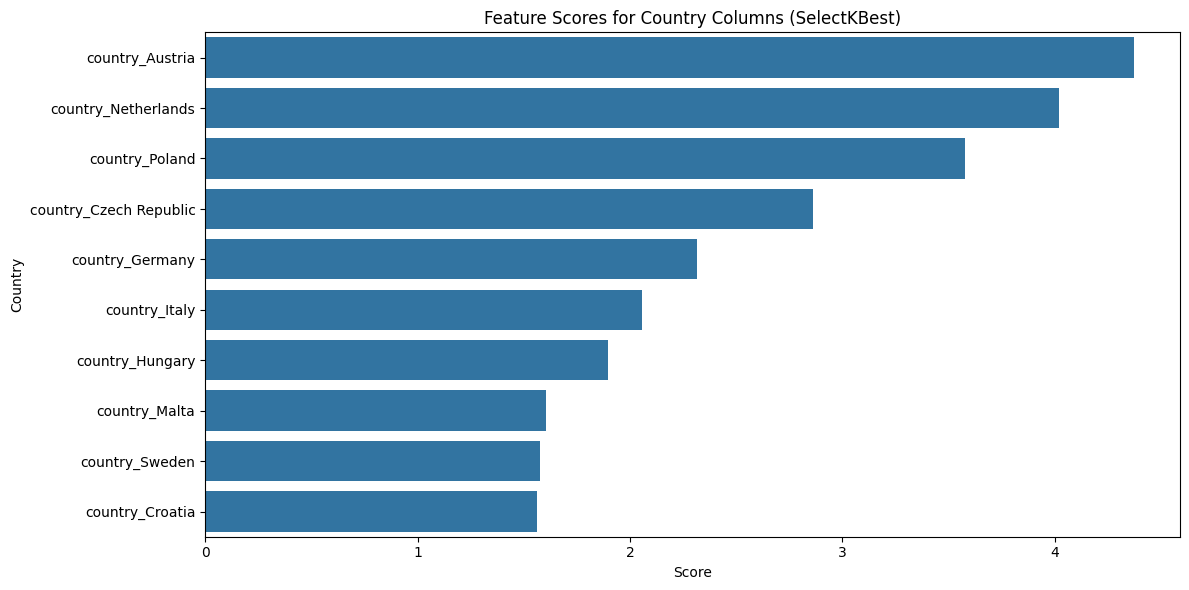

In [21]:
#Visualization

# Get the scores for each feature
scores = selector.scores_

# Create a DataFrame to store feature names and scores
feature_scores = pd.DataFrame({'Feature': features.columns, 'Score': scores})

# Sort the features by score in descending order
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

# Visualize the feature scores
plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Feature', data=feature_scores)
plt.title('Feature Scores for Country Columns (SelectKBest)')
plt.xlabel('Score')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [22]:
# Save the preprocessed DataFrame to a new CSV file
output_path = "/content/preprocessed_lung_cancer_data.csv"
df_cleaned.to_csv(output_path, index=False)

print(f"Preprocessed data saved to: {output_path}")

Preprocessed data saved to: /content/preprocessed_lung_cancer_data.csv
